# Reading Data

In [1]:
import pandas as pd

In [2]:
data = pd.read_excel('data_for_predict.xlsx')
data

,Country,Year,Y,X1,X2
0,Argentina,2013,3550,250,0.61849
1,Argentina,2014,3457,247,0.59396
2,Argentina,2015,3391,247,0.62262
3,Argentina,2016,3358,245,0.55815
4,Argentina,2017,3335,244,0.55631
...,...,...,...,...,...
95,United States,2018,4533,739,2.99045
96,United States,2019,4529,789,3.14704
97,United States,2020,4526,873,3.42467
98,United States,2021,4524,968,3.48313


# Cleaning Data

In [3]:
lr_data = data.drop(['Country','Year'],axis=1)
lr_data

,Y,X1,X2
0,3550,250,0.61849
1,3457,247,0.59396
2,3391,247,0.62262
3,3358,245,0.55815
4,3335,244,0.55631
...,...,...,...
95,4533,739,2.99045
96,4529,789,3.14704
97,4526,873,3.42467
98,4524,968,3.48313


# Modeling

In [4]:
x = lr_data[['X1','X2']]
y = lr_data['Y']

In [5]:
x.corr().abs()

,X1,X2
X1,1.000000,0.252356
X2,0.252356,1.000000


In [6]:
import statsmodels.api as sm

In [7]:
x = sm.add_constant(x)

In [8]:
model = sm.OLS(y,x).fit()

In [9]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     15.35
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           1.61e-06
Time:                        01:23:04   Log-Likelihood:                -776.88
No. Observations:                 100   AIC:                             1560.
Df Residuals:                      97   BIC:                             1568.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3596.4524    131.184     27.415      0.000    3336.089    3856.815
X1            -0.0832      0.032     -2.602      0.011      -0.147      -0.020
X2           345.4610     64.090      5.390      0.000     218.260     472.662
==============================================================================
Omnibus:                       73.368   Durbin-Watson:                   0.234
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              360.523
Skew:                          -2.533   Prob(JB):                     5.17e-79
Kurtosis:                      10.801   Cond. No.                     5.98e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.98e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Applying OLS Model

In [10]:
lr_data = pd.read_excel('for_final_result.xlsx')
lr_data

,Country,Year,Y,X1,X2
0,Cyprus,2022,1817,481,0.74527
1,"Egypt, Arab Rep.",2022,2887,57,1.01968
2,"Iran, Islamic Rep.",2022,2743,140,0.78611
3,Israel,2022,3076,495,6.01924
4,Jordan,2022,2069,226,0.91293
5,Kuwait,2022,2395,23,0.08041
6,Qatar,2022,90,306,0.70418
7,Saudi Arabia,2022,3800,12,0.45278
8,United Arab Emirates,2022,4374,380,1.49469


In [11]:
for_lr = lr_data.drop(['Country','Year'],axis=1)

In [12]:
for_lr

,Y,X1,X2
0,1817,481,0.74527
1,2887,57,1.01968
2,2743,140,0.78611
3,3076,495,6.01924
4,2069,226,0.91293
5,2395,23,0.08041
6,90,306,0.70418
7,3800,12,0.45278
8,4374,380,1.49469


In [13]:
x_predict = for_lr[['X1','X2']]

In [14]:
x_predict = sm.add_constant(x_predict)

In [15]:
result = model.predict(x_predict)
result

0    3813.893766
1    3943.969488
2    3856.374382
3    5634.679625
4    3893.030340
5    3622.317260
6    3814.259181
7    3751.871780
8    4081.192546
dtype: float64

In [16]:
lr_data['YE'] = result

# Visualization

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
lr_data

,Country,Year,Y,X1,X2,YE
0,Cyprus,2022,1817,481,0.74527,3813.893766
1,"Egypt, Arab Rep.",2022,2887,57,1.01968,3943.969488
2,"Iran, Islamic Rep.",2022,2743,140,0.78611,3856.374382
3,Israel,2022,3076,495,6.01924,5634.679625
4,Jordan,2022,2069,226,0.91293,3893.030340
5,Kuwait,2022,2395,23,0.08041,3622.317260
6,Qatar,2022,90,306,0.70418,3814.259181
7,Saudi Arabia,2022,3800,12,0.45278,3751.871780
8,United Arab Emirates,2022,4374,380,1.49469,4081.192546


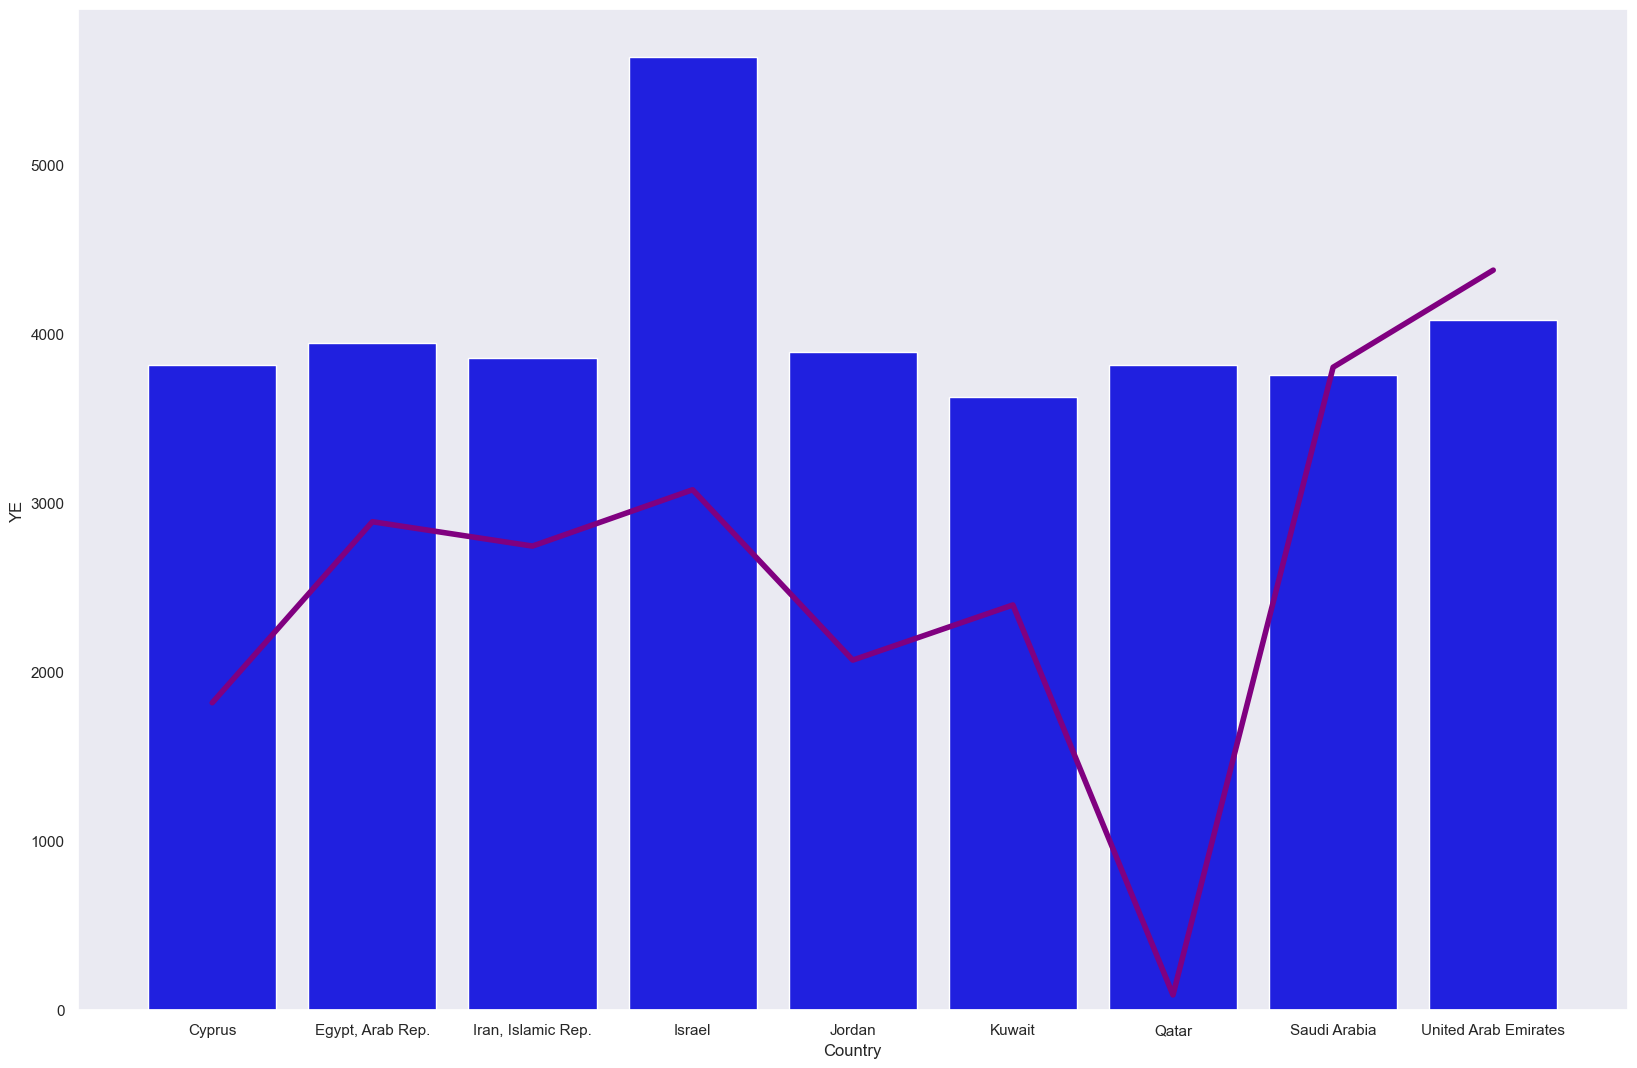

In [41]:
sns.set_theme(style="dark", palette="plasma")
plt.figure(figsize=(20, 13))
sns.barplot(lr_data,x='Country',y='YE',color='blue')
sns.lineplot(lr_data,x='Country',y='Y',color='purple',linewidth=4)
plt.show()

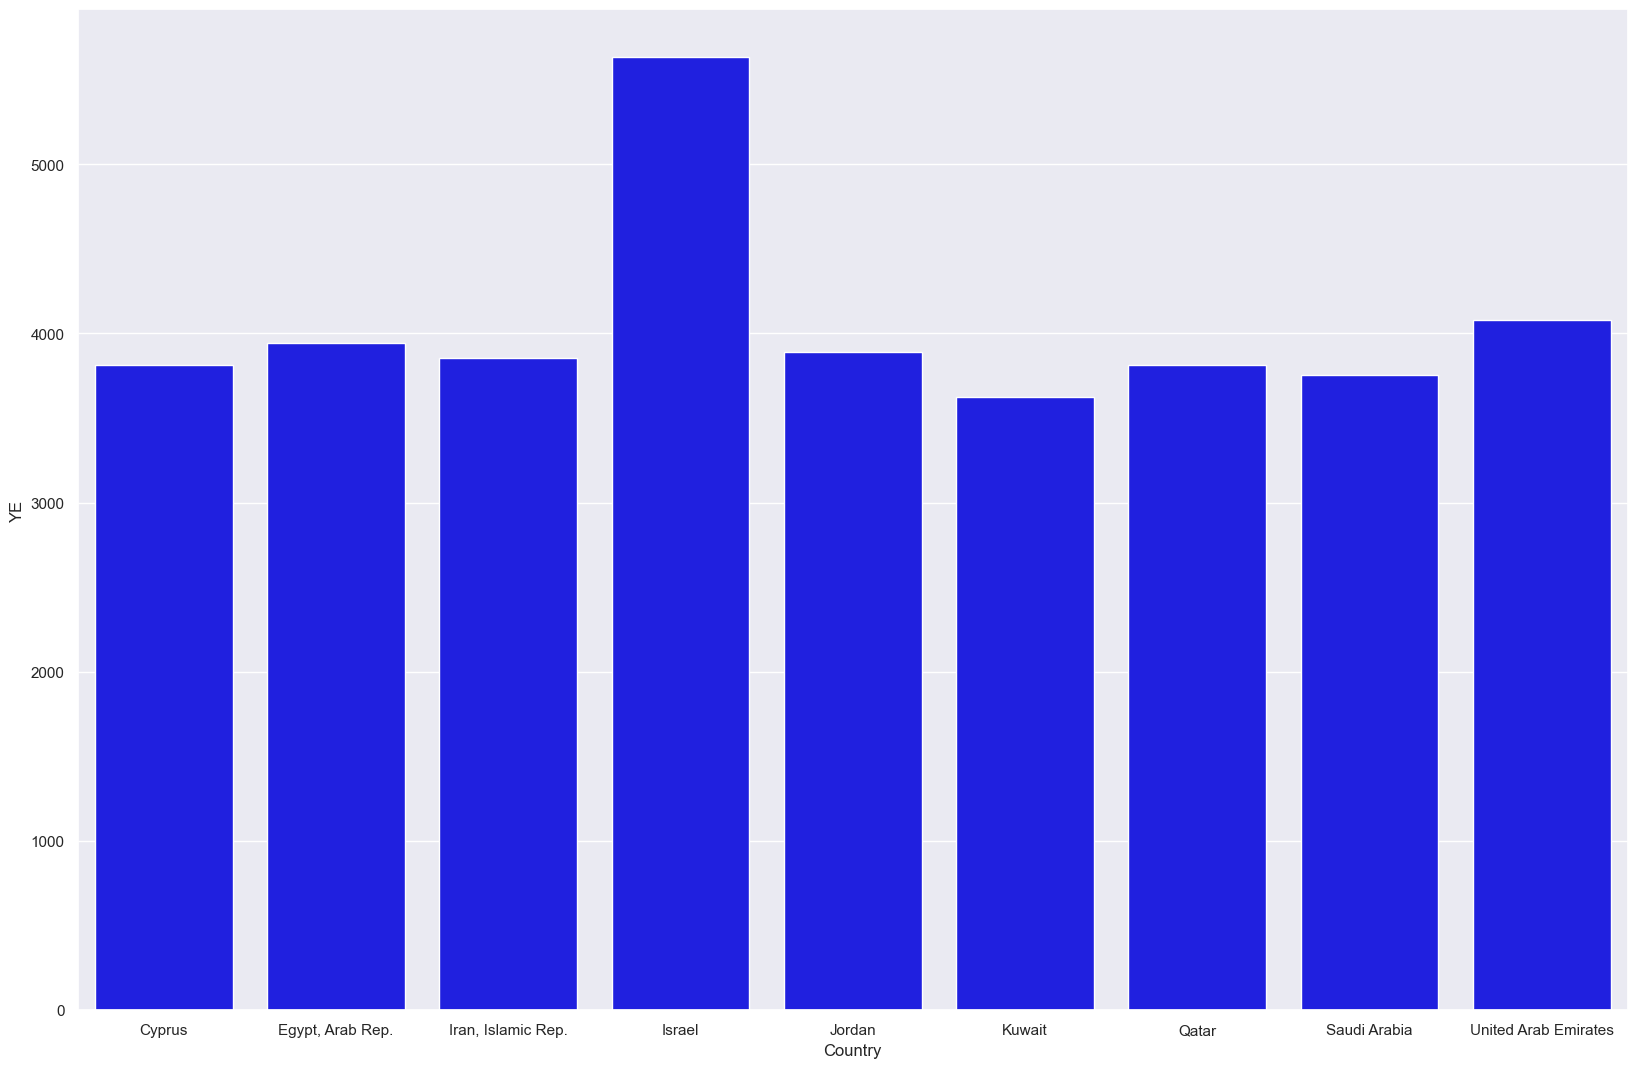

In [19]:
sns.set_theme(style="darkgrid", palette="husl")
plt.figure(figsize=(20, 13))
sns.barplot(lr_data,x="Country",y="YE",color='blue')
plt.show()